In [1]:
# Cell 1 — Title & Introduction (Markdown cell)

# SMS Spam Detection — ML Algorithm Comparison Study

## objective
# Compare Naïve Bayes, Logistic Regression, and KNN algorithms
# on SMS spam detection and find the best performing model.

## Algorithms Compared
# - Naïve Bayes
# - Logistic Regression
# - KNN (K-Nearest Neighbours)

## Libraries Used
# - NumPy, Pandas, Matplotlib, Scikit-learn

In [2]:
# Cell 2 — Import Libraries (Code cell)

# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [3]:
# Cell 3 — Load Dataset (Code cell)

# Load the dataset
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Drop unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Preview
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Cell 4 — Explore Data (Code cell)

# Check class distribution
print("Class Distribution:")
print(df['label'].value_counts())
print("\nSpam percentage:", round(df['label'].value_counts(normalize=True)['spam'] * 100, 2), "%")

# Check for null values
print("\nNull values:", df.isnull().sum().sum())

# Message length analysis
df['msg_length'] = df['message'].apply(len)
print("\nAverage message length:")
print(df.groupby('label')['msg_length'].mean())

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41 %

Null values: 0

Average message length:
label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64


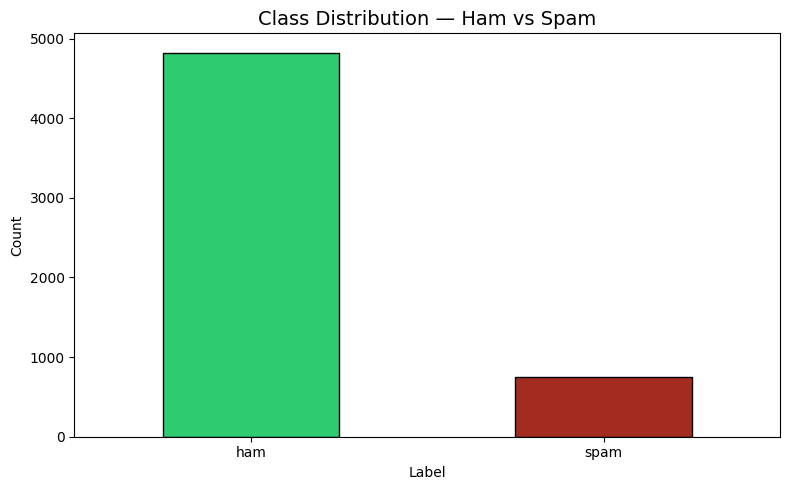

✅ Plot saved!


In [5]:
# Cell 5 — Visualize Class Distribution (Code cell)

# Plot class distribution
plt.figure(figsize=(8,5))
colors = ['#2ecc71', "#a22c1f"]
df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Class Distribution — Ham vs Spam', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/class_distribution.png')
plt.show()
print("✅ Plot saved!")

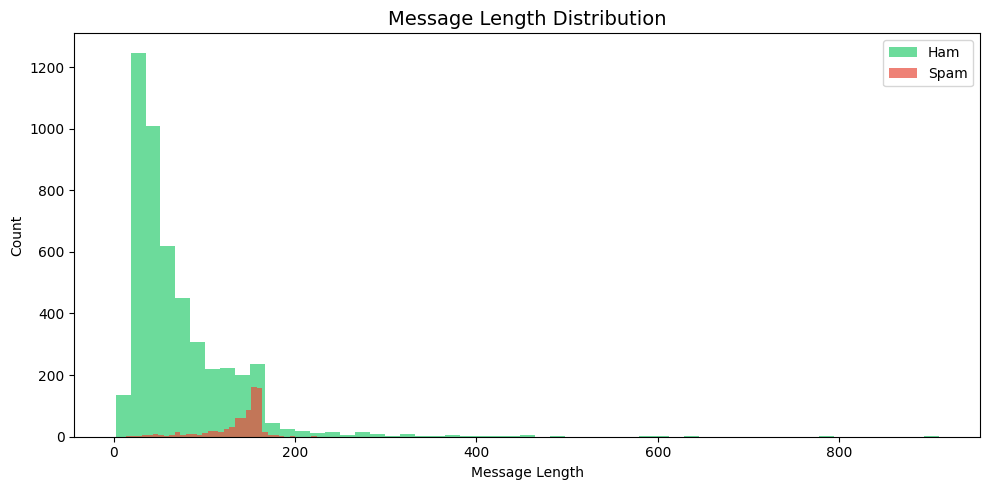

✅ Plot saved!


In [6]:
# Cell 6 — Message Length Distribution (Code cell)

# Plot message length distribution
plt.figure(figsize=(10, 5))
df[df['label'] == 'ham']['msg_length'].plot(kind='hist', bins=55, 
                                             color='#2ecc71', 
                                             alpha=0.7, 
                                             label='Ham')
df[df['label'] == 'spam']['msg_length'].plot(kind='hist', bins=35, 
                                              color='#e74c3c', 
                                              alpha=0.7, 
                                              label='Spam')
plt.title('Message Length Distribution', fontsize=14)
plt.xlabel('Message Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../images/message_length.png')
plt.show()
print("✅ Plot saved!")

In [7]:
# Cell 7 — Text Preprocessing (Code cell)


# Text Preprocessing
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1 - Clean text function
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

# Step 2 - Apply cleaning to all messages
df['clean_message'] = df['message'].apply(clean_text)

# Step 3 - Convert labels to numbers (ham=0, spam=1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Preview
print("Original message:", df['message'][2])
print("Cleaned message:", df['clean_message'][2])
print("\nLabel mapping sample:")
print(df[['label', 'label_num']].head())

Original message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned message: free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s

Label mapping sample:
  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


In [8]:
# Cell 8 — TF-IDF Vectorization

# TF-IDF Vectorization & Train/Test Split

# Step 1 - Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=3000)

# Step 2 - Define X (features) and y (target)
X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['label_num'].values

# Step 3 - Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42)

# Preview
print("Total messages:", len(X))
print("Training size:", len(X_train))
print("Testing size:", len(X_test))
print("Feature matrix shape:", X.shape)


Total messages: 5572
Training size: 4457
Testing size: 1115
Feature matrix shape: (5572, 3000)


In [9]:
# Cell 9 — Training All 3 Models


# Train all 3 models

# Model 1 - Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("✅ Naive Bayes trained!")

# Model 2 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("✅ Logistic Regression trained!")

# Model 3 - KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print("✅ KNN trained!")

✅ Naive Bayes trained!
✅ Logistic Regression trained!
✅ KNN trained!


In [10]:
# Cell 10 — Evaluating All 3 Models

# Evaluate all 3 models

def evaluate_model(name, y_test, y_pred):
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
    print(f"Precision: {round(precision_score(y_test, y_pred) * 100, 2)}%")
    print(f"Recall:    {round(recall_score(y_test, y_pred) * 100, 2)}%")
    print(f"F1 Score:  {round(f1_score(y_test, y_pred) * 100, 2)}%")

# Evaluate all models
evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("KNN", y_test, knn_pred)


Model: Naive Bayes
Accuracy:  97.04%
Precision: 100.0%
Recall:    78.0%
F1 Score:  87.64%

Model: Logistic Regression
Accuracy:  96.5%
Precision: 100.0%
Recall:    74.0%
F1 Score:  85.06%

Model: KNN
Accuracy:  92.11%
Precision: 100.0%
Recall:    41.33%
F1 Score:  58.49%


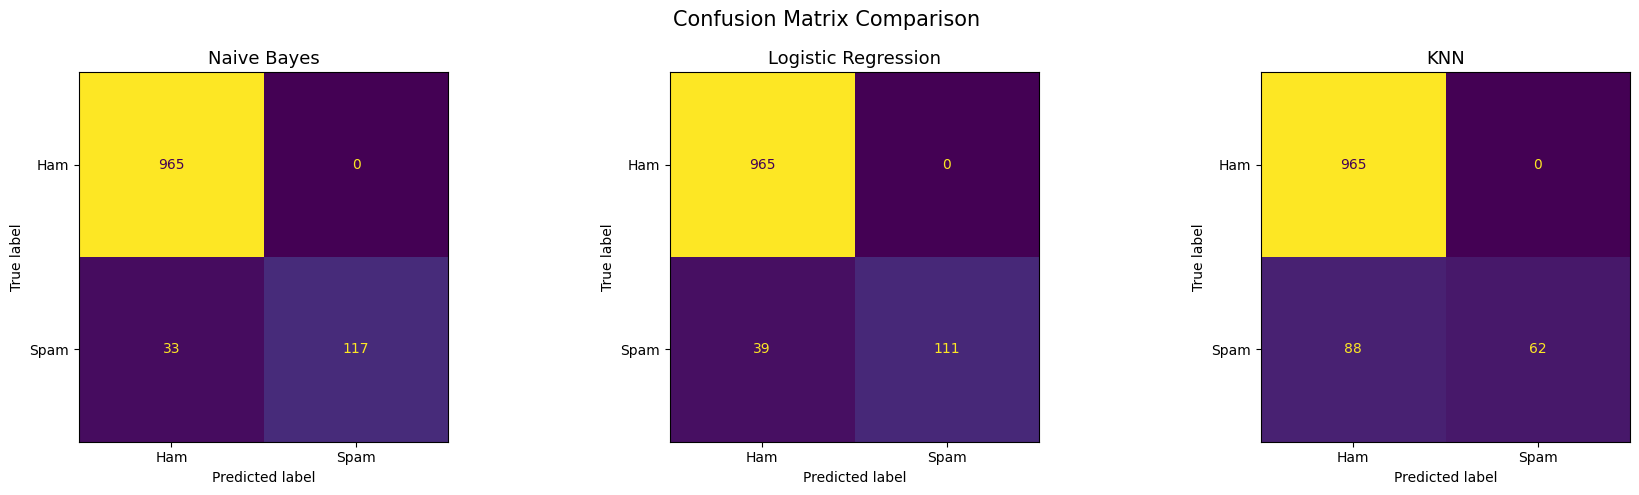

✅ Confusion matrices saved!


In [11]:
# Cell 11 — Confusion Matrix Visualization

# Confusion Matrix for all 3 models

# Step 1 - Setup figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Step 2 - Define models and their predictions
models = [
    ("Naive Bayes", nb_pred),
    ("Logistic Regression", lr_pred),
    ("KNN", knn_pred)
]

# Step 3 - Plot confusion matrix for each model
for i, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=['Ham', 'Spam'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f'{name}', fontsize=13)

# Step 4 - Save and show
plt.suptitle('Confusion Matrix Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('../images/confusion_matrices.png')
plt.show()
print("✅ Confusion matrices saved!")



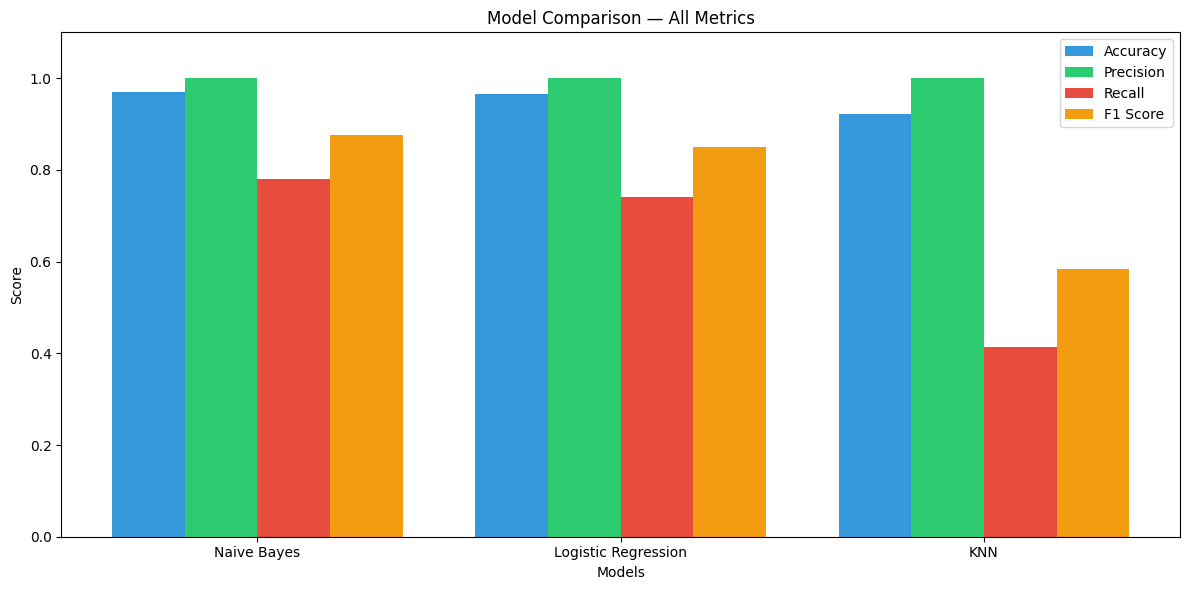

✅ Comparison chart saved!


In [12]:
# Cell 12 — Model Comparison Bar Chart:

# Model Comparison Bar Chart

# Step 1 - Store all metrics
models = ['Naive Bayes', 'Logistic Regression', 'KNN']

accuracy  = [accuracy_score(y_test, nb_pred),
             accuracy_score(y_test, lr_pred),
             accuracy_score(y_test, knn_pred)]

precision = [precision_score(y_test, nb_pred),
             precision_score(y_test, lr_pred),
             precision_score(y_test, knn_pred)]

recall    = [recall_score(y_test, nb_pred),
             recall_score(y_test, lr_pred),
             recall_score(y_test, knn_pred)]

f1        = [f1_score(y_test, nb_pred),
             f1_score(y_test, lr_pred),
             f1_score(y_test, knn_pred)]

# Step 2 - Setup bar positions
x = np.arange(len(models))
width = 0.2

# Step 3 - Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='#3498db')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='#2ecc71')
ax.bar(x + 0.5*width, recall,    width, label='Recall',    color='#e74c3c')
ax.bar(x + 1.5*width, f1,        width, label='F1 Score',  color='#f39c12')

# Step 4 - Labels
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../images/model_comparison.png')
plt.show()
print("✅ Comparison chart saved!")


In [13]:
# Cell 13 — Save Trained Models:


# Save all 3 trained models to disk
import joblib

# Save models
joblib.dump(nb_model,  '../models/naive_bayes_model.pkl')
joblib.dump(lr_model,  '../models/logistic_regression_model.pkl')
joblib.dump(knn_model, '../models/knn_model.pkl')

# Save TF-IDF vectorizer too (important!)
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("✅ All models saved!")
print("✅ TF-IDF vectorizer saved!")

✅ All models saved!
✅ TF-IDF vectorizer saved!


In [ ]:
# Cell 14 — Conclusion (Markdown cell):

## Results & Conclusion

### Final Results Table

# | Model | Accuracy | Precision | Recall | F1 Score |
# |---|---|---|---|---|
# | **Naive Bayes** | 97.04% | 100% | 78% | 87.64% |
# | **Logistic Regression** | 96.5% | 100% | 74% | 85.06% |
# | **KNN** | 92.11% | 100% | 41.33% | 58.49% |

# ### Winner: Naive Bayes 🥇

# ### Key Findings:
# - All models achieved 100% Precision
# - Naive Bayes had best Recall (78%) and F1 Score (87.64%)
# - KNN performed worst with only 41% Recall
# - Spam messages are 2x longer than ham messages on average

# ### Why Naive Bayes wins on text data:
# - Specifically designed for text classification
# - Calculates word probability for spam vs ham
# - Fast, simple and highly effective on NLP tasks

# ### Author
# **Jiveshwar Singh Rathore**  
# Aspiring ML Engineer
